In [1]:
import pandas as pd
from sklearn.model_selection import train_test_split
import numpy as np
import pickle
import matplotlib.pyplot as plt
from sklearn.preprocessing import StandardScaler,LabelEncoder






In [2]:
data=pd.read_csv("Churn_Modelling.csv")
data.head()

,RowNumber,CustomerId,Surname,CreditScore,Geography,Gender,Age,Tenure,Balance,NumOfProducts,HasCrCard,IsActiveMember,EstimatedSalary,Exited
0,1,15634602,Hargrave,619,France,Female,42,2,0.00,1,1,1,101348.88,1
1,2,15647311,Hill,608,Spain,Female,41,1,83807.86,1,0,1,112542.58,0
2,3,15619304,Onio,502,France,Female,42,8,159660.80,3,1,0,113931.57,1
3,4,15701354,Boni,699,France,Female,39,1,0.00,2,0,0,93826.63,0
4,5,15737888,Mitchell,850,Spain,Female,43,2,125510.82,1,1,1,79084.10,0


In [3]:
data.info()
data.isnull().sum()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 10000 entries, 0 to 9999
Data columns (total 14 columns):
 #   Column           Non-Null Count  Dtype  
---  ------           --------------  -----  
 0   RowNumber        10000 non-null  int64  
 1   CustomerId       10000 non-null  int64  
 2   Surname          10000 non-null  object 
 3   CreditScore      10000 non-null  int64  
 4   Geography        10000 non-null  object 
 5   Gender           10000 non-null  object 
 6   Age              10000 non-null  int64  
 7   Tenure           10000 non-null  int64  
 8   Balance          10000 non-null  float64
 9   NumOfProducts    10000 non-null  int64  
 10  HasCrCard        10000 non-null  int64  
 11  IsActiveMember   10000 non-null  int64  
 12  EstimatedSalary  10000 non-null  float64
 13  Exited           10000 non-null  int64  
dtypes: float64(2), int64(9), object(3)
memory usage: 1.1+ MB


RowNumber          0
CustomerId         0
Surname            0
CreditScore        0
Geography          0
Gender             0
Age                0
Tenure             0
Balance            0
NumOfProducts      0
HasCrCard          0
IsActiveMember     0
EstimatedSalary    0
Exited             0
dtype: int64

In [4]:
data=data.drop(columns=['RowNumber','CustomerId','Surname'],axis=1)
data

,CreditScore,Geography,Gender,Age,Tenure,Balance,NumOfProducts,HasCrCard,IsActiveMember,EstimatedSalary,Exited
0,619,France,Female,42,2,0.00,1,1,1,101348.88,1
1,608,Spain,Female,41,1,83807.86,1,0,1,112542.58,0
2,502,France,Female,42,8,159660.80,3,1,0,113931.57,1
3,699,France,Female,39,1,0.00,2,0,0,93826.63,0
4,850,Spain,Female,43,2,125510.82,1,1,1,79084.10,0
...,...,...,...,...,...,...,...,...,...,...,...
9995,771,France,Male,39,5,0.00,2,1,0,96270.64,0
9996,516,France,Male,35,10,57369.61,1,1,1,101699.77,0
9997,709,France,Female,36,7,0.00,1,0,1,42085.58,1
9998,772,Germany,Male,42,3,75075.31,2,1,0,92888.52,1


IndexError: index 9 is out of bounds for axis 0 with size 9

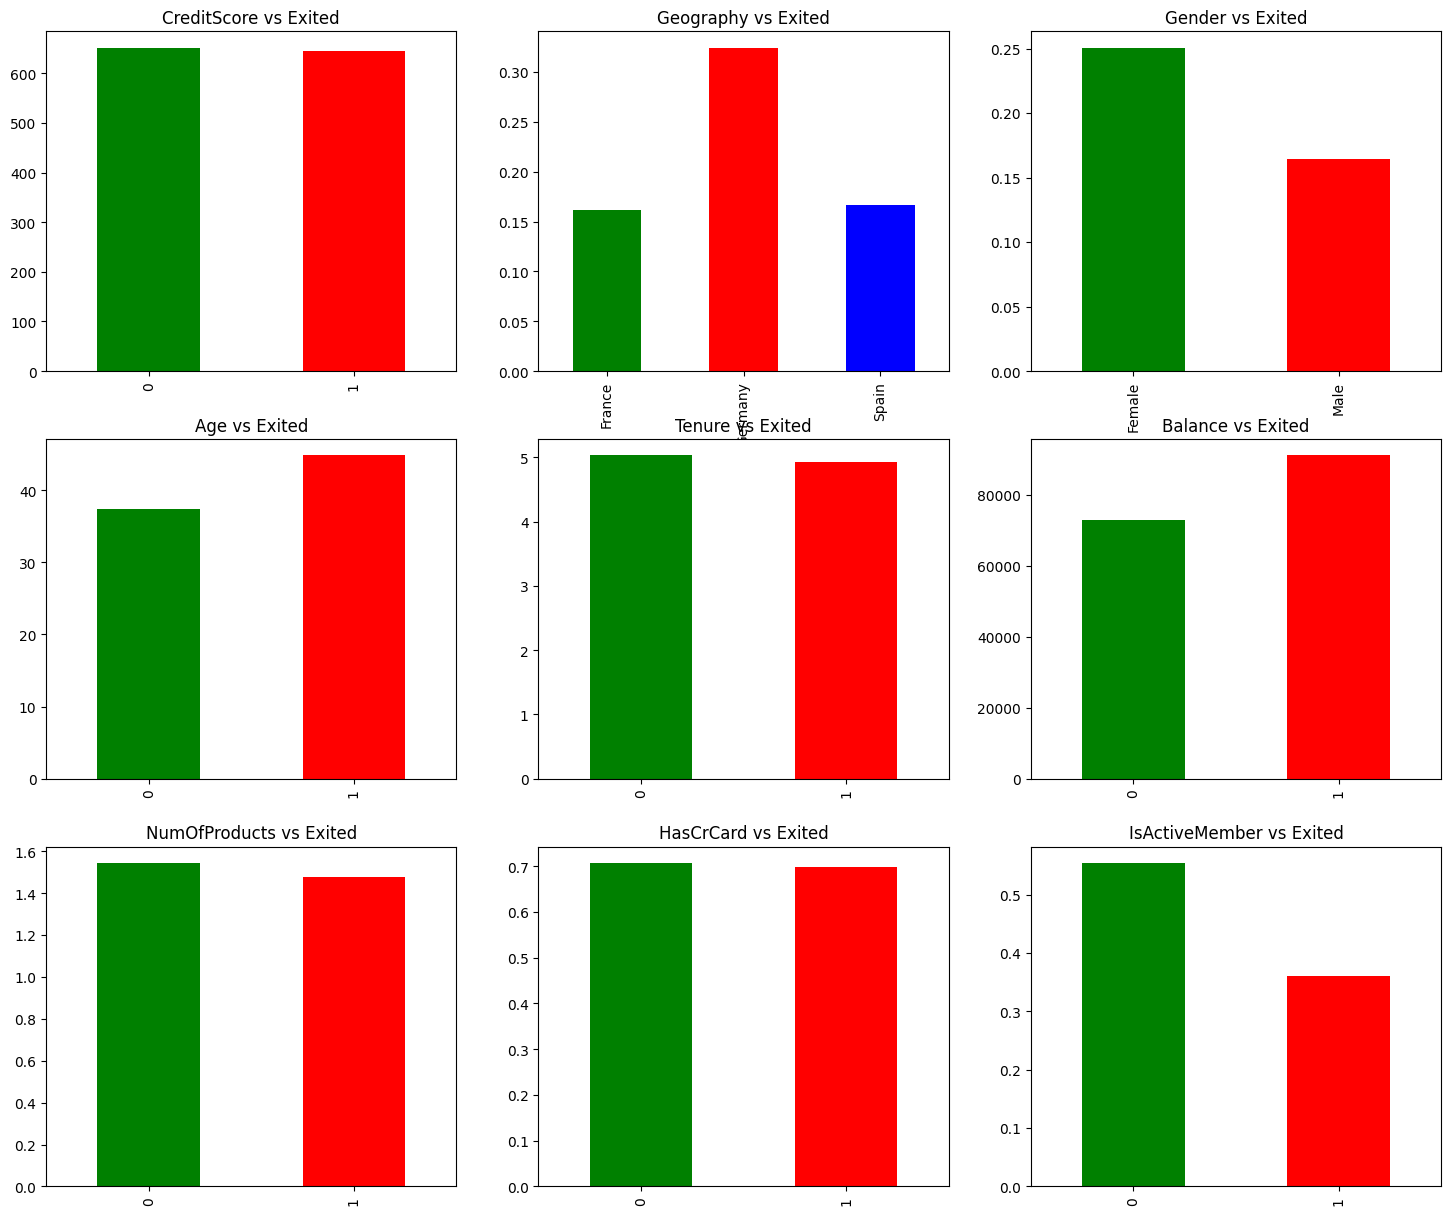

In [5]:
fig,axes=plt.subplots(3,3, figsize=(18,15))
axes=axes.flatten()
cols=['CreditScore','Geography','Gender','Age','Tenure','Balance','NumOfProducts','HasCrCard','IsActiveMember','EstimatedSalary']
for i,col in enumerate(cols):
    if data[col].dtype=='object':
        data.groupby(col)['Exited'].mean().plot(kind='bar',ax=axes[i],color=['green','red','blue'])
    else:
        data.groupby('Exited')[col].mean().plot(kind='bar', ax=axes[i],color=['green','red'])
    axes[i].set_title(f'{col} vs Exited')
    axes[i].set_xlabel('')

for i in range(len(cols), len(axes)):
    axes[i].set_visible(False)

plt.tight_layout()
plt.show()
    

In [6]:
label_encoder_gender=LabelEncoder()
data['Gender']=label_encoder_gender.fit_transform(data['Gender'])
data

,CreditScore,Geography,Gender,Age,Tenure,Balance,NumOfProducts,HasCrCard,IsActiveMember,EstimatedSalary,Exited
0,619,France,0,42,2,0.00,1,1,1,101348.88,1
1,608,Spain,0,41,1,83807.86,1,0,1,112542.58,0
2,502,France,0,42,8,159660.80,3,1,0,113931.57,1
3,699,France,0,39,1,0.00,2,0,0,93826.63,0
4,850,Spain,0,43,2,125510.82,1,1,1,79084.10,0
...,...,...,...,...,...,...,...,...,...,...,...
9995,771,France,1,39,5,0.00,2,1,0,96270.64,0
9996,516,France,1,35,10,57369.61,1,1,1,101699.77,0
9997,709,France,0,36,7,0.00,1,0,1,42085.58,1
9998,772,Germany,1,42,3,75075.31,2,1,0,92888.52,1


In [7]:
## onehot encode 'Geography'
from sklearn.preprocessing import OneHotEncoder
onehot_encoder_geo=OneHotEncoder()
geo_encoder=onehot_encoder_geo.fit_transform(data[['Geography']]).toarray()
geo_encoder

array([[1., 0., 0.],
       [0., 0., 1.],
       [1., 0., 0.],
       ...,
       [1., 0., 0.],
       [0., 1., 0.],
       [1., 0., 0.]])

In [8]:
onehot_encoder_geo.get_feature_names_out(['Geography'])

array(['Geography_France', 'Geography_Germany', 'Geography_Spain'],
      dtype=object)

In [9]:
geo_encoder_df=pd.DataFrame(geo_encoder,columns=onehot_encoder_geo.get_feature_names_out(['Geography']))
geo_encoder_df

,Geography_France,Geography_Germany,Geography_Spain
0,1.0,0.0,0.0
1,0.0,0.0,1.0
2,1.0,0.0,0.0
3,1.0,0.0,0.0
4,0.0,0.0,1.0
...,...,...,...
9995,1.0,0.0,0.0
9996,1.0,0.0,0.0
9997,1.0,0.0,0.0
9998,0.0,1.0,0.0


In [10]:
data=pd.concat([data.drop('Geography',axis=1),geo_encoder_df],axis=1)
data

,CreditScore,Gender,Age,Tenure,Balance,NumOfProducts,HasCrCard,IsActiveMember,EstimatedSalary,Exited,Geography_France,Geography_Germany,Geography_Spain
0,619,0,42,2,0.00,1,1,1,101348.88,1,1.0,0.0,0.0
1,608,0,41,1,83807.86,1,0,1,112542.58,0,0.0,0.0,1.0
2,502,0,42,8,159660.80,3,1,0,113931.57,1,1.0,0.0,0.0
3,699,0,39,1,0.00,2,0,0,93826.63,0,1.0,0.0,0.0
4,850,0,43,2,125510.82,1,1,1,79084.10,0,0.0,0.0,1.0
...,...,...,...,...,...,...,...,...,...,...,...,...,...
9995,771,1,39,5,0.00,2,1,0,96270.64,0,1.0,0.0,0.0
9996,516,1,35,10,57369.61,1,1,1,101699.77,0,1.0,0.0,0.0
9997,709,0,36,7,0.00,1,0,1,42085.58,1,1.0,0.0,0.0
9998,772,1,42,3,75075.31,2,1,0,92888.52,1,0.0,1.0,0.0


In [11]:
## save the encoders and scaler
with open('label_encoder_gender.pkl','wb')as file:
    pickle.dump(label_encoder_gender,file)

with open('onehot_encoder_geo.pkl','wb')as file:
    pickle.dump(onehot_encoder_geo,file)

In [12]:
correlation=data.drop(columns='Exited')

In [13]:
cor=correlation.corr()
cor
  



    


,CreditScore,Gender,Age,Tenure,Balance,NumOfProducts,HasCrCard,IsActiveMember,EstimatedSalary,Geography_France,Geography_Germany,Geography_Spain
CreditScore,1.000000,-0.002857,-0.003965,0.000842,0.006268,0.012238,-0.005458,0.025651,-0.001384,-0.008928,0.005538,0.004780
Gender,-0.002857,1.000000,-0.027544,0.014733,0.012087,-0.021859,0.005766,0.022544,-0.008112,0.006772,-0.024628,0.016889
Age,-0.003965,-0.027544,1.000000,-0.009997,0.028308,-0.030680,-0.011721,0.085472,-0.007201,-0.039208,0.046897,-0.001685
Tenure,0.000842,0.014733,-0.009997,1.000000,-0.012254,0.013444,0.022583,-0.028362,0.007784,-0.002848,-0.000567,0.003868
Balance,0.006268,0.012087,0.028308,-0.012254,1.000000,-0.304180,-0.014858,-0.010084,0.012797,-0.231329,0.401110,-0.134892
NumOfProducts,0.012238,-0.021859,-0.030680,0.013444,-0.304180,1.000000,0.003183,0.009612,0.014204,0.001230,-0.010419,0.009039
HasCrCard,-0.005458,0.005766,-0.011721,0.022583,-0.014858,0.003183,1.000000,-0.011866,-0.009933,0.002467,0.010577,-0.013480
IsActiveMember,0.025651,0.022544,0.085472,-0.028362,-0.010084,0.009612,-0.011866,1.000000,-0.011421,0.003317,-0.020486,0.016732
EstimatedSalary,-0.001384,-0.008112,-0.007201,0.007784,0.012797,0.014204,-0.009933,-0.011421,1.000000,-0.003332,0.010297,-0.006482
Geography_France,-0.008928,0.006772,-0.039208,-0.002848,-0.231329,0.001230,0.002467,0.003317,-0.003332,1.000000,-0.580359,-0.575418


In [14]:
cols=cor.columns
print("="*7)
print(f"{'colimn1':25}{'column2':25}{'correlation':25}{'Strength'}")
print("="*75)

for i in range(len(cols)):
    for j in range(i+1, len(cols)):
        col1=cols[i]
        col2=cols[j]
        corr_value=cor[col1][col2]

        if abs(corr_value)>=0.5:
            strength="Strong"
        elif abs(corr_value)>=0.2:
            strength='Medium'

        elif abs(corr_value)>=0.1:
            strength='Weak'

        else:
            strength="No Correlation"

        print(f"{col1:25}{col2:25}{corr_value:15.4f}{strength:20}")
print("="*75)

colimn1                  column2                  correlation              Strength
CreditScore              Gender                           -0.0029No Correlation      
CreditScore              Age                              -0.0040No Correlation      
CreditScore              Tenure                            0.0008No Correlation      
CreditScore              Balance                           0.0063No Correlation      
CreditScore              NumOfProducts                     0.0122No Correlation      
CreditScore              HasCrCard                        -0.0055No Correlation      
CreditScore              IsActiveMember                    0.0257No Correlation      
CreditScore              EstimatedSalary                  -0.0014No Correlation      
CreditScore              Geography_France                 -0.0089No Correlation      
CreditScore              Geography_Germany                 0.0055No Correlation      
CreditScore              Geography_Spain                

In [15]:
data.head()

,CreditScore,Gender,Age,Tenure,Balance,NumOfProducts,HasCrCard,IsActiveMember,EstimatedSalary,Exited,Geography_France,Geography_Germany,Geography_Spain
0,619,0,42,2,0.00,1,1,1,101348.88,1,1.0,0.0,0.0
1,608,0,41,1,83807.86,1,0,1,112542.58,0,0.0,0.0,1.0
2,502,0,42,8,159660.80,3,1,0,113931.57,1,1.0,0.0,0.0
3,699,0,39,1,0.00,2,0,0,93826.63,0,1.0,0.0,0.0
4,850,0,43,2,125510.82,1,1,1,79084.10,0,0.0,0.0,1.0


In [16]:
## divide the dataset into independent and dependent features
X=data.drop('Exited',axis=1)
y=data['Exited']

##split the data in training and testing sets
x_train,x_test,y_train,y_test=train_test_split(X,y,test_size=0.2,random_state=42)

##scale these features
scaler=StandardScaler()
x_train=scaler.fit_transform(x_train)
x_test=scaler.transform(x_test)

In [17]:
x_train

array([[ 0.35649971,  0.91324755, -0.6557859 , ...,  1.00150113,
        -0.57946723, -0.57638802],
       [-0.20389777,  0.91324755,  0.29493847, ..., -0.99850112,
         1.72572313, -0.57638802],
       [-0.96147213,  0.91324755, -1.41636539, ..., -0.99850112,
        -0.57946723,  1.73494238],
       ...,
       [ 0.86500853, -1.09499335, -0.08535128, ...,  1.00150113,
        -0.57946723, -0.57638802],
       [ 0.15932282,  0.91324755,  0.3900109 , ...,  1.00150113,
        -0.57946723, -0.57638802],
       [ 0.47065475,  0.91324755,  1.15059039, ..., -0.99850112,
         1.72572313, -0.57638802]])

In [18]:
with open('scaler.pkl','wb')as file:
    pickle.dump(scaler,file)

In [19]:
x_train.shape[1]    ## 12 indicates the column which we had. 

12

In [20]:
import tensorflow as tf
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Dense
from tensorflow.keras.callbacks import EarlyStopping,TensorBoard
import datetime

In [33]:
x_train.shape[1]

12

In [34]:
model=Sequential([
    Dense(64,activation='relu',input_shape=(x_train.shape[1],)),
    Dense(32,activation='relu'),
    Dense(1,activation='sigmoid')])

In [35]:
model.summary()

Model: "sequential_1"
_________________________________________________________________
 Layer (type)                Output Shape              Param #   
 dense_3 (Dense)             (None, 64)                832       
                                                                 
 dense_4 (Dense)             (None, 32)                2080      
                                                                 
 dense_5 (Dense)             (None, 1)                 33        
                                                                 
Total params: 2945 (11.50 KB)
Trainable params: 2945 (11.50 KB)
Non-trainable params: 0 (0.00 Byte)
_________________________________________________________________


In [36]:
import tensorflow
opt=tensorflow.keras.optimizers.Adam(learning_rate=0.01)
loss=tensorflow.keras.losses.BinaryCrossentropy()
loss

In [37]:
#compile the model
model.compile(optimizer=opt,loss=loss,metrics=['accuracy'])

In [38]:
# set up the tensorboard
from tensorflow.keras.callbacks import EarlyStopping,TensorBoard
log_dir="logs/fit/" + datetime.datetime.now().strftime("%Y%m%d-%H%M%S")
tensorflow_callback=TensorBoard(log_dir=log_dir,histogram_freq=1)  # here log weight histograms every 1 epoch

In [39]:
## setup early stopping 
early_stopping_callback=EarlyStopping(monitor='val_loss',patience=10,restore_best_weights=True)  #EarlyStopping is a CALLBACK that AUTOMATICALLY STOPS training when the model stops improving

In [40]:
## train the model
history=model.fit(x_train,y_train,validation_data=(x_test,y_test),epochs=100,callbacks=[tensorflow_callback,early_stopping_callback])

Epoch 1/100
250/250 [==============================] - 1s 2ms/step - loss: 0.3997 - accuracy: 0.8324 - val_loss: 0.3556 - val_accuracy: 0.8610
Epoch 2/100
250/250 [==============================] - 0s 2ms/step - loss: 0.3563 - accuracy: 0.8547 - val_loss: 0.3570 - val_accuracy: 0.8480
Epoch 3/100
250/250 [==============================] - 0s 2ms/step - loss: 0.3480 - accuracy: 0.8596 - val_loss: 0.3535 - val_accuracy: 0.8515
Epoch 4/100
250/250 [==============================] - 1s 2ms/step - loss: 0.3448 - accuracy: 0.8587 - val_loss: 0.3518 - val_accuracy: 0.8580
Epoch 5/100
250/250 [==============================] - 1s 2ms/step - loss: 0.3414 - accuracy: 0.8597 - val_loss: 0.3413 - val_accuracy: 0.8595
Epoch 6/100
250/250 [==============================] - 1s 2ms/step - loss: 0.3360 - accuracy: 0.8624 - val_loss: 0.3441 - val_accuracy: 0.8640
Epoch 7/100
250/250 [==============================] - 1s 2ms/step - loss: 0.3349 - accuracy: 0.8601 - val_loss: 0.3541 - val_accuracy: 0.8545

In [41]:
model.save("model.h5")

In [42]:
## load tensorboard extension
%load_ext tensorboard

The tensorboard extension is already loaded. To reload it, use:
  %reload_ext tensorboard


In [45]:
%reload_ext tensorboard

In [50]:
!netstat -ano | findstr :6006

In [52]:
from tensorboard import notebook
notebook.list() 


Known TensorBoard instances:
  - port 6007: logdir logs/fit20260413-112351 (started 1 day, 7:27:27 ago; pid 49848)
  - port 6006: logdir logs/fit (started 1 day, 7:31:06 ago; pid 50392)


In [54]:
%tensorboard --logdir logs/fit --port 6008

Reusing TensorBoard on port 6008 (pid 17644), started 0:00:14 ago. (Use '!kill 17644' to kill it.)